# Machine Learning Modeling 

## Import Libraries

In [1]:
# import general python packages 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

# import classfier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# import model selection and preprocessing tools 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, f1_score


## Import Data 

In [2]:
X_train = pd.read_csv("data/X_train.csv", sep=",", low_memory= False) 
X_test = pd.read_csv("data/X_test.csv", sep=",", low_memory=False)

y_train = pd.read_csv("data/y_train.csv", sep=",", low_memory=False) 
y_test = pd.read_csv("data/y_test.csv", sep=",", low_memory=False) 

# Check lengths 
print(f"X: {len(X_train)}, y: {len(y_train)}")

X: 1524, y: 1524


## Define the Datasets

- **Dataset 1:** Full feature set. Remove rows with missing values in Polyphen_Score and SIFT_Score.
- **Dataset 2:** Exlude the features 'Polyphen_Score','SIFT_Score' 'missing_Polyphen', 'missing_SIFT'. 
- **Dataset 3:** Exclude the feature 'Consequence'. Remove missing values in 'Polyphen_Score' and 'SIFT_Score'.
- **Dataset 4:** Exclude the features 'Polyphen_Score', 'SIFT_Score', 'missing_Polyphen', 'missing_SIFT', 'Consequence'.
- **Dataset 5:** Full feature set. Impute -1 in rows with missing Polyphen and SIFT scores. 

## Create Datasets

### Define columns to handle

In [3]:
# Define columns to handle 
score_columns = ["Polyphen_Score", "SIFT_Score"] 
missing_columns = ["missing_Polyphen", "missing_SIFT"] 
consequence_column = ["Consequence"]

### Check column names

In [4]:
# Check column names
print(X_train.columns.tolist())

['Consequence', 'Variant_Type', 'has_gnomAD_AF', 'Polyphen_Score', 'SIFT_Score', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'missing_Polyphen', 'missing_SIFT', 'gnomAD_AF_log', 'hotspot_x_vartype']


### Dataset 1

In [5]:
# Dataset 1: Full feature set, remove rows with missing values 
mask_train = X_train[score_columns].notna().all(axis=1) 
mask_test = X_test[score_columns].notna().all(axis=1) 

X_train_1 = X_train[mask_train].copy()
y_train_1 = y_train[mask_train].copy()
X_test_1 = X_test[mask_test].copy()
y_test_1 = y_test[mask_test].copy()

# control that no rows has missing values 
print(f"X_train_1 has {(X_train_1.isna().sum().sum())} missing values.") 

X_train_1 has 0 missing values.


In [6]:
print("The five first rows of X_train_1:")  
display(X_train_1.head())

The five first rows of X_train_1:


,Consequence,Variant_Type,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,missing_Polyphen,missing_SIFT,gnomAD_AF_log,hotspot_x_vartype
0,missense_variant,SNP,False,0.908,0.00,False,False,0,False,0,0,0,-6.000000,False_SNP
1,missense_variant,SNP,True,0.007,0.08,False,True,1,False,0,0,0,-5.301436,False_SNP
2,missense_variant,SNP,False,0.087,0.31,False,False,0,False,0,0,0,-6.000000,False_SNP
3,missense_variant,SNP,False,0.497,0.01,False,True,1,True,1,0,0,-6.000000,False_SNP
4,missense_variant,SNP,True,0.586,0.01,False,False,0,True,1,0,0,-5.047830,False_SNP


### Dataset 2

In [7]:
# Dataset 2: Exlude the features 'Polyphen_Score','SIFT_Score' 'missing_Polyphen', 'missing_SIFT'. 
cols_to_drop_2 = score_columns + missing_columns 
X_train_2 = X_train.drop(columns=cols_to_drop_2)
X_test_2 = X_test.drop(columns=cols_to_drop_2)
y_train_2 = y_train.copy()
y_test_2 = y_test.copy()

# Check column names in the new dataset 
print(X_train_2.columns.tolist())

# control that no rows has missing values 
print(f"X_train_2 has {(X_train_2.isna().sum().sum())} missing values.")

['Consequence', 'Variant_Type', 'has_gnomAD_AF', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'gnomAD_AF_log', 'hotspot_x_vartype']
X_train_2 has 0 missing values.


In [8]:
print("The five first rows of X_train_2:")  
display(X_train_2.head())

The five first rows of X_train_2:


,Consequence,Variant_Type,has_gnomAD_AF,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,gnomAD_AF_log,hotspot_x_vartype
0,missense_variant,SNP,False,False,False,0,False,0,-6.000000,False_SNP
1,missense_variant,SNP,True,False,True,1,False,0,-5.301436,False_SNP
2,missense_variant,SNP,False,False,False,0,False,0,-6.000000,False_SNP
3,missense_variant,SNP,False,False,True,1,True,1,-6.000000,False_SNP
4,missense_variant,SNP,True,False,False,0,True,1,-5.047830,False_SNP


### Dataset 3 

In [9]:
# Dataset 3: exclude the column 'Consequence', remove missing values in Polyphen and SIFT. 
mask_train = X_train[score_columns].notna().all(axis=1)
mask_test = X_test[score_columns].notna().all(axis=1)

X_train_3 = X_train[mask_train].drop(columns=consequence_column)
X_test_3 = X_test[mask_test].drop(columns=consequence_column)
y_train_3 = y_train[mask_train].copy()
y_test_3 = y_test[mask_test].copy()

# control column names
print(X_train_3.columns.tolist())

# control that no rows has missing values 
print(f"X_train_3 has {(X_train_3.isna().sum().sum())} missing values.")

['Variant_Type', 'has_gnomAD_AF', 'Polyphen_Score', 'SIFT_Score', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'missing_Polyphen', 'missing_SIFT', 'gnomAD_AF_log', 'hotspot_x_vartype']
X_train_3 has 0 missing values.


In [10]:
print("The five first rows of X_train_3:")  
display(X_train_3.head())

The five first rows of X_train_3:


,Variant_Type,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,missing_Polyphen,missing_SIFT,gnomAD_AF_log,hotspot_x_vartype
0,SNP,False,0.908,0.00,False,False,0,False,0,0,0,-6.000000,False_SNP
1,SNP,True,0.007,0.08,False,True,1,False,0,0,0,-5.301436,False_SNP
2,SNP,False,0.087,0.31,False,False,0,False,0,0,0,-6.000000,False_SNP
3,SNP,False,0.497,0.01,False,True,1,True,1,0,0,-6.000000,False_SNP
4,SNP,True,0.586,0.01,False,False,0,True,1,0,0,-5.047830,False_SNP


### Dataset 4 

In [11]:
cols_to_drop_4 = score_columns + missing_columns + consequence_column

X_train_4 = X_train.drop(columns=cols_to_drop_4)
X_test_4 = X_test.drop(columns=cols_to_drop_4)
y_train_4 = y_train.copy()
y_test_4 = y_test.copy()

# control column names
print(X_train_4.columns.tolist())

# control that no rows has missing values 
print(f"X_train_4 has {(X_train_4.isna().sum().sum())} missing values.")  

['Variant_Type', 'has_gnomAD_AF', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'gnomAD_AF_log', 'hotspot_x_vartype']
X_train_4 has 0 missing values.


In [12]:
print("The five first rows of X_train_4:")  
display(X_train_4.head())

The five first rows of X_train_4:


,Variant_Type,has_gnomAD_AF,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,gnomAD_AF_log,hotspot_x_vartype
0,SNP,False,False,False,0,False,0,-6.000000,False_SNP
1,SNP,True,False,True,1,False,0,-5.301436,False_SNP
2,SNP,False,False,False,0,False,0,-6.000000,False_SNP
3,SNP,False,False,True,1,True,1,-6.000000,False_SNP
4,SNP,True,False,False,0,True,1,-5.047830,False_SNP


### Dataset 5

In [13]:
# Check which variant types have missing SIFT/Polyphen
print(X_train[X_train['SIFT_Score'].isna()]['Variant_Type'].value_counts())
print(X_train[X_train['Polyphen_Score'].isna()]['Variant_Type'].value_counts())

X_train_5 = X_train.copy()
X_test_5 = X_test.copy()

impute_cols = ['SIFT_Score', 'Polyphen_Score']
X_train_5[impute_cols] = X_train_5[impute_cols].fillna(-1)
X_test_5[impute_cols] = X_test_5[impute_cols].fillna(-1)

y_train_5 = y_train.copy()
y_test_5 = y_test.copy()

Variant_Type
DEL    219
INS     50
ONP     21
TNP     15
SNP     14
DNP      7
Name: count, dtype: int64
Variant_Type
DEL    219
INS     50
ONP     21
TNP     15
SNP     14
DNP      7
Name: count, dtype: int64


In [14]:
# Check for missing values 
print(f"X_train_5 has {X_train_5.isna().sum().sum()} missing values.")

X_train_5 has 0 missing values.


## Define the Pipelines

In [15]:
categorical_feat = ["Variant_Type", "has_gnomAD_AF", "Consequence", "In_Hotspot", "IN_DOMAIN", "IN_FUNC_SITE", 'hotspot_x_vartype']

def create_pipeline(df, model, categorical_feat): 
  """
  Creates ML-pipeline based on categorical columns in df, 
  for the chosen ML classifier. 
  """
  existing_cat = [c for c in categorical_feat if c in df.columns]
  existing_num = df.columns.difference(existing_cat).tolist() 

  preprocessor = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), existing_num),
            ('cat', OneHotEncoder(handle_unknown='ignore'), existing_cat)
        ])
  
  return Pipeline([
    ('preprocessor', preprocessor),
    ('clf', model)
  ])

In [ ]:
# Define the logistic regression pipeline
pipe_logistic1 = create_pipeline(X_train_1, LogisticRegression(max_iter=5000), categorical_feat)
pipe_logistic2 = create_pipeline(X_train_2, LogisticRegression(max_iter=5000), categorical_feat)
pipe_logistic3 = create_pipeline(X_train_3, LogisticRegression(max_iter=5000), categorical_feat)
pipe_logistic4 = create_pipeline(X_train_4, LogisticRegression(max_iter=5000), categorical_feat)
pipe_logistic5 = create_pipeline(X_train_5, LogisticRegression(max_iter=5000), categorical_feat)

# Define the random forest pipeline
pipe_rf1 = create_pipeline(X_train_1, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf2 = create_pipeline(X_train_2, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf3 = create_pipeline(X_train_3, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf4 = create_pipeline(X_train_4, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf5 = create_pipeline(X_train_5, RandomForestClassifier(random_state=1), categorical_feat) 


# Define the xgboost pipeline 
pipe_xgb1 = create_pipeline(X_train_1, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb2 = create_pipeline(X_train_2, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb3 = create_pipeline(X_train_3, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb4 = create_pipeline(X_train_4, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb5 = create_pipeline(X_train_5, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)

## **ML Modeling**

## Linear Regression Model

### Define CV-strategy, pipeline, and hyperparameters to test 

In [ ]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

logistic1 = GridSearchCV(
  estimator=pipe_logistic1, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear', 'saga'],
              'clf__class_weight': ['balanced', None]
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic2 = GridSearchCV(
  estimator=pipe_logistic2, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear', 'saga'],
              'clf__class_weight': ['balanced', None]
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic3 = GridSearchCV(
  estimator=pipe_logistic3, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear', 'saga'],
              'clf__class_weight': ['balanced', None]
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic4 = GridSearchCV(
  estimator=pipe_logistic4, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear', 'saga'],
              'clf__class_weight': ['balanced', None]
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic5 = GridSearchCV(
  estimator=pipe_logistic5, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear', 'saga'],
              'clf__class_weight': ['balanced', None]
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)


### Fit logistic model to all training data 

In [18]:
logistic1 = logistic1.fit(X_train_1, y_train_1.values.ravel())

print(f"The best F1-score (Macro) for dataset 1: {logistic1.best_score_}")
print(f"The best hyperparameters: {logistic1.best_params_}")

logistic2 = logistic2.fit(X_train_2, y_train_2.values.ravel())

print(f"The best F1-score (Macro) for dataset 2: {logistic2.best_score_}")
print(f"The best hyperparameters: {logistic2.best_params_}")

logistic3 = logistic3.fit(X_train_3, y_train_3.values.ravel())

print(f"The best F1-score (Macro) for dataset 3: {logistic3.best_score_}")
print(f"The best hyperparameters: {logistic3.best_params_}")

logistic4 = logistic4.fit(X_train_4, y_train_4.values.ravel())

print(f"The best F1-score (Macro) for dataset 4: {logistic4.best_score_}")
print(f"The best hyperparameters: {logistic4.best_params_}")

logistic5 = logistic5.fit(X_train_5, y_train_5.values.ravel())

print(f"The best F1-score (Macro) for dataset 5: {logistic5.best_score_}")
print(f"The best hyperparameters: {logistic5.best_params_}")

/home/anekl/git/master/machine_learning_pipeline/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/anekl/git/master/machine_learning_pipeline/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/anekl/git/master/machine_learning_pipeline/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/anekl/git/master/machine_learning_pipeline/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/anekl/git/master/machine_learning_pipeline/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: Conver

The best F1-score (Macro) for dataset 1: 0.7535136672232181
The best hyperparameters: {'clf__C': 1, 'clf__class_weight': None, 'clf__l1_ratio': 1, 'clf__solver': 'liblinear'}
The best F1-score (Macro) for dataset 2: 0.7322051615881069
The best hyperparameters: {'clf__C': 0.001, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0, 'clf__solver': 'liblinear'}


NameError: name 'logistic3' is not defined

### Evaluate model performance

### Dataset 1

In [ ]:
# Predict classes for dataset 1 
y_pred_1 = logistic1.predict(X_test_1)

# Predict probabilities
y_probs_1 = logistic1.predict_proba(X_test_1)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_1, y_pred_1, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_1))

Test F1-score (Macro): 0.7135

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.85      0.76       162
           1       0.78      0.58      0.67       150

    accuracy                           0.72       312
   macro avg       0.74      0.72      0.71       312
weighted avg       0.73      0.72      0.72       312



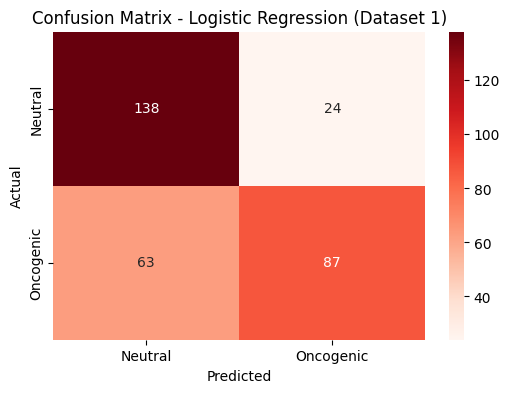

In [ ]:
cm = confusion_matrix(y_test_1, y_pred_1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Dataset 1)')
plt.show()

### Dataset 2

In [ ]:
# Predict classes for dataset 2
y_pred_2 = logistic2.predict(X_test_2)

# Predict probabilities
y_probs_2 = logistic2.predict_proba(X_test_2)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_2, y_pred_2, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_2, y_pred_2))

Test F1-score (Macro): 0.7315

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.90      0.75       172
           1       0.88      0.60      0.71       210

    accuracy                           0.73       382
   macro avg       0.76      0.75      0.73       382
weighted avg       0.77      0.73      0.73       382



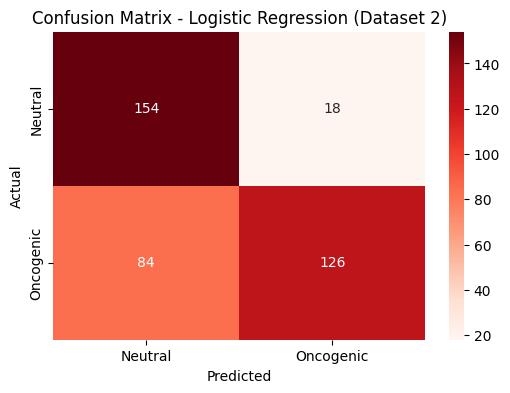

In [ ]:
cm = confusion_matrix(y_test_2, y_pred_2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Dataset 2)')
plt.show()

### Dataset 3

In [ ]:
# Predict classes for dataset 3
y_pred_3 = logistic3.predict(X_test_3)

# Predict probabilities
y_probs_3 = logistic3.predict_proba(X_test_3)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_3, y_pred_3, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_3, y_pred_3))

Test F1-score (Macro): 0.7099

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.85      0.76       162
           1       0.78      0.57      0.66       150

    accuracy                           0.72       312
   macro avg       0.73      0.71      0.71       312
weighted avg       0.73      0.72      0.71       312



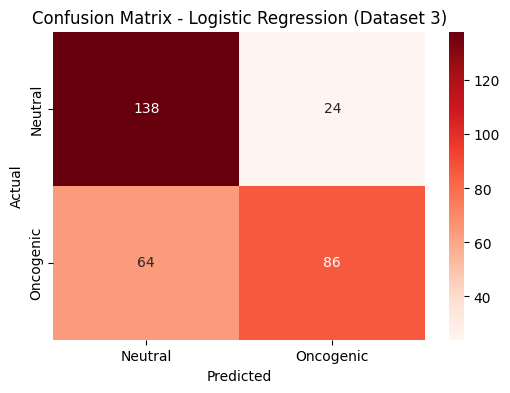

In [ ]:
cm = confusion_matrix(y_test_3, y_pred_3)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Dataset 3)')
plt.show()

### Dataset 4

In [ ]:
# Predict classes for dataset 4
y_pred_4 = logistic4.predict(X_test_4)

# Predict probabilities
y_probs_4 = logistic4.predict_proba(X_test_4)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_4, y_pred_4, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_4, y_pred_4))

Test F1-score (Macro): 0.7290

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.89      0.75       172
           1       0.87      0.60      0.71       210

    accuracy                           0.73       382
   macro avg       0.76      0.74      0.73       382
weighted avg       0.77      0.73      0.73       382



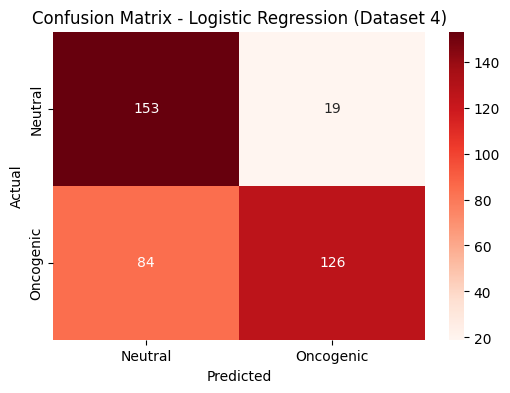

In [ ]:
cm = confusion_matrix(y_test_4, y_pred_4)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Dataset 4)')
plt.show()

### Dataset 5

In [ ]:
# Predict classes for dataset 5
y_pred_5 = logistic5.predict(X_test_5)

# Predict probabilities
y_probs_5 = logistic5.predict_proba(X_test_5)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_5, y_pred_5, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_5, y_pred_5))

Test F1-score (Macro): 0.7195

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.84      0.73       172
           1       0.83      0.62      0.71       210

    accuracy                           0.72       382
   macro avg       0.74      0.73      0.72       382
weighted avg       0.75      0.72      0.72       382



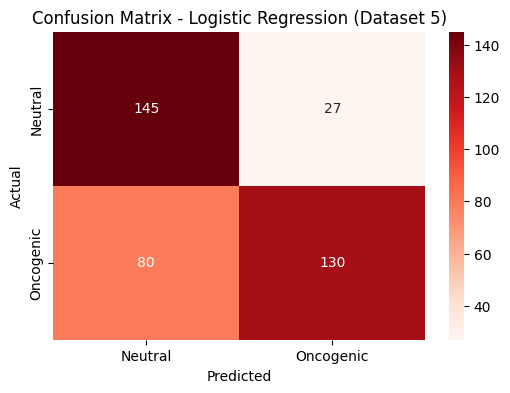

In [ ]:
cm = confusion_matrix(y_test_5, y_pred_5)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Dataset 5)')
plt.show()

## Random Forest Model

### Define CV-strategy and hyperparameters to test 

In [ ]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

rf1 = GridSearchCV(
  estimator=pipe_rf1,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

rf2 = GridSearchCV(
  estimator=pipe_rf2,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

rf3 = GridSearchCV(
  estimator=pipe_rf3,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

rf4 = GridSearchCV(
  estimator=pipe_rf4,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

rf5 = GridSearchCV(
  estimator=pipe_rf5,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

### Fit random forest model to all training data 

In [ ]:
rf1 = rf1.fit(X_train_1, y_train_1.values.ravel()) 

print(rf1.best_score_)
print(rf1.best_params_)

print(f"The best F1-score (Macro) for dataset 1: {rf1.best_score_}")
print(f"The best hyperparameters: {rf1.best_params_}")

rf2 = rf2.fit(X_train_2, y_train_2.values.ravel()) 

print(rf2.best_score_)
print(rf2.best_params_)

print(f"The best F1-score (Macro) for dataset 2: {rf2.best_score_}")
print(f"The best hyperparameters: {rf2.best_params_}")

rf3 = rf3.fit(X_train_3, y_train_3.values.ravel()) 

print(rf3.best_score_)
print(rf3.best_params_)

print(f"The best F1-score (Macro) for dataset 3: {rf3.best_score_}")
print(f"The best hyperparameters: {rf3.best_params_}")


rf4 = rf4.fit(X_train_4, y_train_4.values.ravel()) 

print(rf4.best_score_)
print(rf4.best_params_)

print(f"The best F1-score (Macro) for dataset 4: {rf4.best_score_}")
print(f"The best hyperparameters: {rf4.best_params_}")

rf5 = rf5.fit(X_train_5, y_train_5.values.ravel()) 

print(rf5.best_score_)
print(rf5.best_params_)

print(f"The best F1-score (Macro) for dataset 5: {rf5.best_score_}")
print(f"The best hyperparameters: {rf5.best_params_}")

0.7628672203429413
{'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 225}
The best F1-score (Macro) for dataset 1: 0.7628672203429413
The best hyperparameters: {'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 225}


### Evaluate model performance 

Dataset 1

In [ ]:
# Predict classes for dataset 1 
y_pred_1 = rf1.predict(X_test_1)

# Predict probabilities
y_probs_1 = rf1.predict_proba(X_test_1)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_1, y_pred_1, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_1))

Test F1-score (Macro): 0.7418

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76       162
           1       0.76      0.69      0.72       150

    accuracy                           0.74       312
   macro avg       0.75      0.74      0.74       312
weighted avg       0.74      0.74      0.74       312



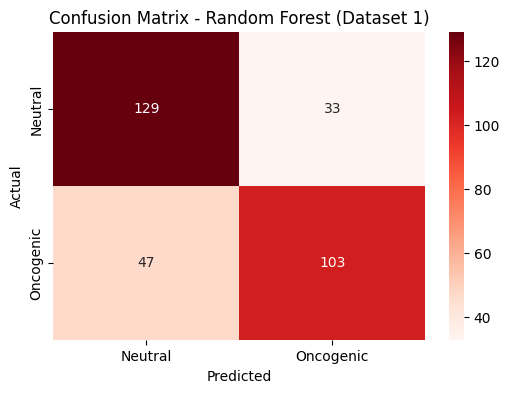

In [ ]:
cm = confusion_matrix(y_test_1, y_pred_1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Dataset 1)')
plt.show()

Dataset 2

In [ ]:
# Predict classes for dataset 2
y_pred_2 = rf2.predict(X_test_2)

# Predict probabilities
y_probs_2 = rf2.predict_proba(X_test_2)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_2, y_pred_2, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_2, y_pred_2))

Test F1-score (Macro): 0.7403

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.77      0.73       172
           1       0.79      0.71      0.75       210

    accuracy                           0.74       382
   macro avg       0.74      0.74      0.74       382
weighted avg       0.75      0.74      0.74       382



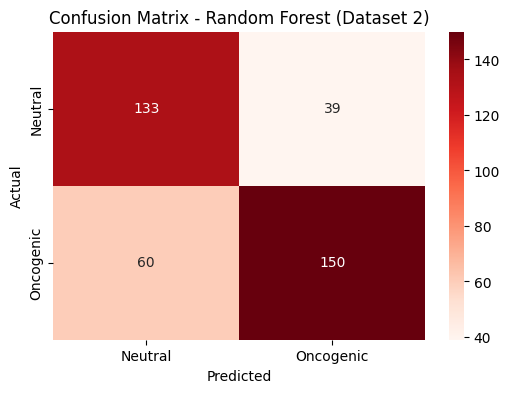

In [ ]:
cm = confusion_matrix(y_test_2, y_pred_2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Dataset 2)')
plt.show()

Dataset 3

In [ ]:
# Predict classes for dataset 3 
y_pred_3 = rf3.predict(X_test_3)

# Predict probabilities
y_probs_3 = rf3.predict_proba(X_test_3)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_3, y_pred_3, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_3, y_pred_3))

Test F1-score (Macro): 0.7258

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75       162
           1       0.74      0.67      0.70       150

    accuracy                           0.73       312
   macro avg       0.73      0.73      0.73       312
weighted avg       0.73      0.73      0.73       312



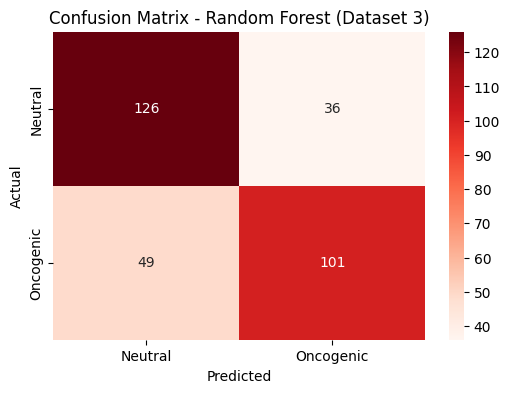

In [ ]:
cm = confusion_matrix(y_test_3, y_pred_3)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Dataset 3)')
plt.show()

Dataset 4

In [ ]:
# Predict classes for dataset 4
y_pred_4 = rf4.predict(X_test_4)

# Predict probabilities
y_probs_4 = rf4.predict_proba(X_test_4)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_4, y_pred_4, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_4, y_pred_4))

Test F1-score (Macro): 0.7275

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.77      0.72       172
           1       0.79      0.69      0.74       210

    accuracy                           0.73       382
   macro avg       0.73      0.73      0.73       382
weighted avg       0.74      0.73      0.73       382



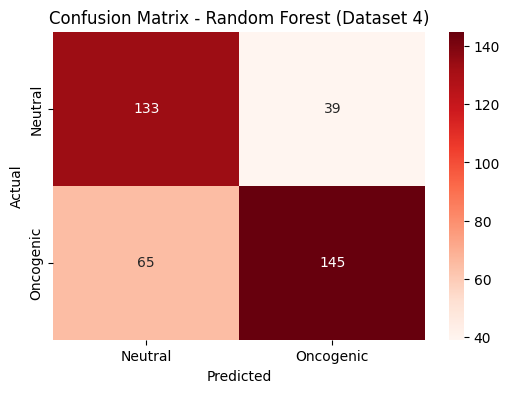

In [ ]:
cm = confusion_matrix(y_test_4, y_pred_4)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Dataset 4)')
plt.show()

### Dataset 5

In [ ]:
# Predict classes for dataset 5
y_pred_5 = rf5.predict(X_test_5)

# Predict probabilities
y_probs_5 = rf5.predict_proba(X_test_5)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_5, y_pred_5, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_5, y_pred_5))

Test F1-score (Macro): 0.7530

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.77      0.74       172
           1       0.80      0.74      0.77       210

    accuracy                           0.75       382
   macro avg       0.75      0.76      0.75       382
weighted avg       0.76      0.75      0.75       382



Text(0.5, 1.0, 'Confusion Matrix - Random Forest (Dataset 5)')

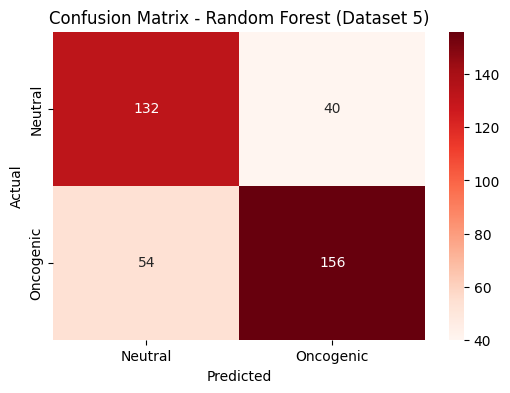

In [ ]:
cm = confusion_matrix(y_test_5, y_pred_5)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Dataset 5)')

### Feature importances Random Forest 

In [ ]:
# Define the best model 
best_model = rf5.best_estimator_

# Get feature names 
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

num__Polyphen_Score                                                0.236796
num__SIFT_Score                                                    0.153336
cat__hotspot_x_vartype_False_SNP                                   0.088139
num__gnomAD_AF_log                                                 0.070011
cat__In_Hotspot_False                                              0.056810
cat__In_Hotspot_True                                               0.056336
cat__hotspot_x_vartype_True_SNP                                    0.051485
num__n_func_sites                                                  0.023707
cat__has_gnomAD_AF_True                                            0.021135
cat__Consequence_missense_variant                                  0.020018
cat__has_gnomAD_AF_False                                           0.019579
cat__IN_FUNC_SITE_True                                             0.018628
cat__IN_FUNC_SITE_False                                            0.016724
num__n_prote

## XGBoost modeling

### Define CV-strategy and hyperparameters to test 

In [ ]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

xgb1 = GridSearchCV(pipe_xgb1, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.02],
                        'clf__max_depth': [3, 5],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1]})

xgb2 = GridSearchCV(pipe_xgb2, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.02],
                        'clf__max_depth': [3, 5],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1]})

xgb3 = GridSearchCV(pipe_xgb3, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.02],
                        'clf__max_depth': [3, 5],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1]})

xgb4 = GridSearchCV(pipe_xgb4, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.02],
                        'clf__max_depth': [3, 5],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1]})

xgb5 = GridSearchCV(pipe_xgb5, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.02],
                        'clf__max_depth': [3, 5],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1]})

In [ ]:
xgb1 = xgb1.fit(X_train_1, y_train_1.values.ravel()) 

print(xgb1.best_score_)
print(xgb1.best_params_)

print(f"The best F1-score (Macro) for dataset 1: {xgb1.best_score_}")
print(f"The best hyperparameters: {xgb1.best_params_}")

xgb2 = xgb2.fit(X_train_2, y_train_2.values.ravel()) 

print(xgb2.best_score_)
print(xgb2.best_params_)

print(f"The best F1-score (Macro) for dataset 2: {xgb2.best_score_}")
print(f"The best hyperparameters: {xgb2.best_params_}")

xgb3 = xgb3.fit(X_train_3, y_train_3.values.ravel()) 

print(xgb3.best_score_)
print(xgb3.best_params_)

print(f"The best F1-score (Macro) for dataset 3: {xgb3.best_score_}")
print(f"The best hyperparameters: {xgb3.best_params_}")

xgb4 = xgb4.fit(X_train_4, y_train_4.values.ravel()) 

print(xgb4.best_score_)
print(xgb4.best_params_)

print(f"The best F1-score (Macro) for dataset 4: {xgb4.best_score_}")
print(f"The best hyperparameters: {xgb4.best_params_}")

xgb5 = xgb5.fit(X_train_5, y_train_5.values.ravel()) 

print(xgb5.best_score_)
print(xgb5.best_params_)

print(f"The best F1-score (Macro) for dataset 5: {xgb5.best_score_}")
print(f"The best hyperparameters: {xgb5.best_params_}")

0.7596234309623431
{'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.01, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
The best F1-score (Macro) for dataset 1: 0.7596234309623431
The best hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.01, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
0.7276855047454702
{'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.02, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
The best F1-score (Macro) for dataset 2: 0.7276855047454702
The best hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.02, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
0.7571269177126918
{'clf__colsample_bytree': 0.8, 'clf__gamma': 0.1, 'clf__learning_rate': 0.02, 'clf__max_depth': 5, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
The best F1-score (Macro) for dataset 3

### Evaluate Model Performance

### Dataset 1

In [ ]:
# Predict classes for dataset 1 
y_pred_1 = xgb1.predict(X_test_1)

# Predict probabilities
y_probs_1 = xgb1.predict_proba(X_test_1)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_1, y_pred_1, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_1))

Test F1-score (Macro): 0.7255

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75       162
           1       0.74      0.67      0.70       150

    accuracy                           0.73       312
   macro avg       0.73      0.73      0.73       312
weighted avg       0.73      0.73      0.73       312



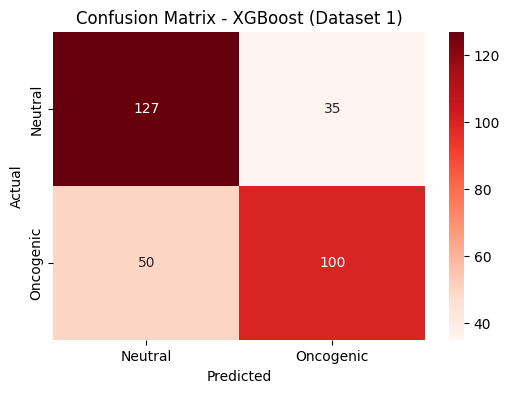

In [ ]:
cm = confusion_matrix(y_test_1, y_pred_1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (Dataset 1)')
plt.show()

### Dataset 2

In [ ]:
# Predict classes for dataset 2
y_pred_2 = xgb2.predict(X_test_2)

# Predict probabilities
y_probs_2 = xgb2.predict_proba(X_test_2)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_2, y_pred_2, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_2, y_pred_2))

Test F1-score (Macro): 0.7376

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.77      0.73       172
           1       0.79      0.71      0.75       210

    accuracy                           0.74       382
   macro avg       0.74      0.74      0.74       382
weighted avg       0.74      0.74      0.74       382



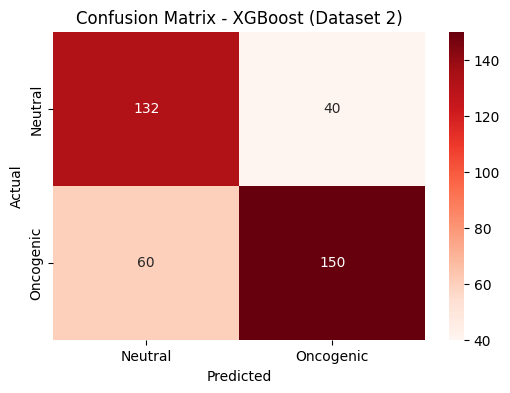

In [ ]:
cm = confusion_matrix(y_test_2, y_pred_2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (Dataset 2)')
plt.show()

### Dataset 3

In [ ]:
# Predict classes for dataset 3 
y_pred_3 = xgb3.predict(X_test_3)

# Predict probabilities
y_probs_3 = xgb3.predict_proba(X_test_3)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_3, y_pred_3, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_3, y_pred_3))

Test F1-score (Macro): 0.7180

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.80      0.75       162
           1       0.74      0.64      0.69       150

    accuracy                           0.72       312
   macro avg       0.72      0.72      0.72       312
weighted avg       0.72      0.72      0.72       312



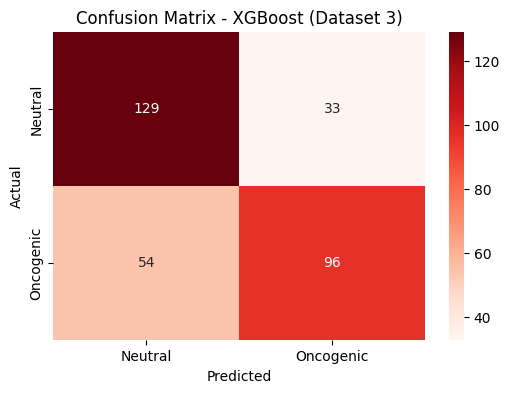

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_3, y_pred_3)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (Dataset 3)')
plt.show()

### Dataset 4

In [ ]:
# Predict classes for dataset 4 
y_pred_4 = xgb4.predict(X_test_4)

# Predict probabilities
y_probs_4 = xgb4.predict_proba(X_test_4)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_4, y_pred_4, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_4, y_pred_4))

Test F1-score (Macro): 0.7317

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.89      0.75       172
           1       0.87      0.60      0.71       210

    accuracy                           0.73       382
   macro avg       0.76      0.75      0.73       382
weighted avg       0.77      0.73      0.73       382



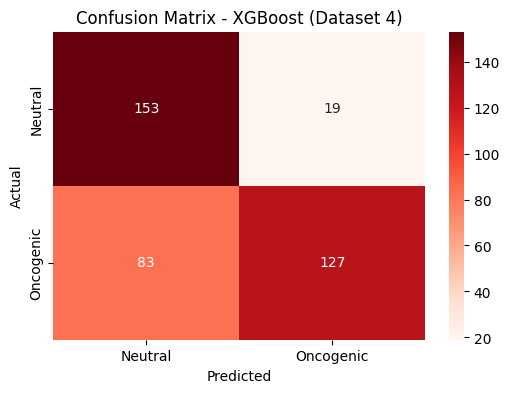

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_4, y_pred_4)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (Dataset 4)')
plt.show()

### Dataset 5

In [ ]:
# Predict classes for dataset 5
y_pred_5 = xgb5.predict(X_test_5)

# Predict probabilities
y_probs_5 = xgb5.predict_proba(X_test_5)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_5, y_pred_5, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_5, y_pred_5))

Test F1-score (Macro): 0.7442

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.73      0.72       172
           1       0.78      0.76      0.77       210

    accuracy                           0.75       382
   macro avg       0.74      0.74      0.74       382
weighted avg       0.75      0.75      0.75       382



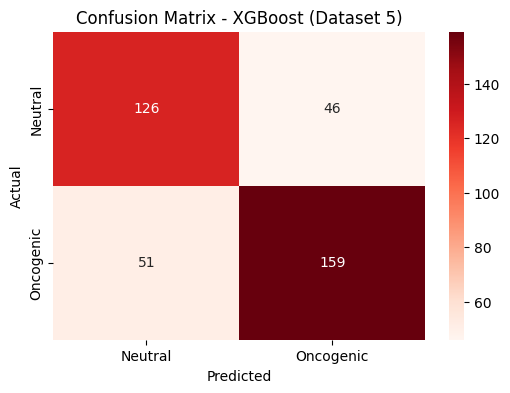

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_5, y_pred_5)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (Dataset 5)')
plt.show()

### Feature Importances XGBoost

In [ ]:
# Define the best model 
best_model = xgb5.best_estimator_

# Get feature names 
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

cat__hotspot_x_vartype_False_SNP                                   0.368661
cat__In_Hotspot_False                                              0.056525
cat__In_Hotspot_True                                               0.041407
cat__Variant_Type_DEL                                              0.031680
cat__Consequence_missense_variant                                  0.027013
cat__Consequence_frameshift_variant                                0.024431
cat__hotspot_x_vartype_False_TNP                                   0.022550
cat__has_gnomAD_AF_True                                            0.022130
cat__hotspot_x_vartype_False_DNP                                   0.021456
cat__hotspot_x_vartype_False_DEL                                   0.021362
cat__Consequence_inframe_insertion                                 0.020352
cat__hotspot_x_vartype_True_SNP                                    0.020330
cat__has_gnomAD_AF_False                                           0.020180
cat__Consequ